In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset processing

In [ ]:
import pandas as pd
import numpy as np

train_path = '/content/drive/MyDrive/E-KAT/mitbih/mitbih_train.csv'
test_path = '/content/drive/MyDrive/E-KAT/mitbih/mitbih_test.csv'

def load_ecg_data(file_path):
    df = pd.read_csv(file_path, header=None)
    signals = df.iloc[:, :187].values
    labels = df.iloc[:, 187].values
    return signals, labels

X_train, y_train = load_ecg_data(train_path)
X_test, y_test = load_ecg_data(test_path)

print(f"shape of train set: {X_train.shape}")
print(f"shape of test set: {X_test.shape}")

X_all = np.vstack((X_train, X_test))
y_all = np.concatenate((y_train, y_test))
X_all = X_all.astype(np.float32)

print(f"shape of all wave: {X_all.shape}")
print(f"shape of all label: {y_all.shape}")

shape of train set: (87554, 187)
shape of test set: (21892, 187)
shape of all wave: (109446, 187)
shape of all label: (109446,)


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA, FastICA

# print("Extract 99% of the main components using PCA.")
# pca = PCA(n_components=0.99, whiten=True)
# X_pca = pca.fit_transform(X_all)

# print(f"The number of features after PCA dimensionality reduction: {X_pca.shape[1]}")

# # ICA - Independent Component Analysis
# print("The ICA independent component decomposition is currently underway.")
# ica = FastICA(n_components=X_pca.shape[1], random_state=42, max_iter=500)
# X_ica = ica.fit_transform(X_pca)

# # signal reconstruction
# X_reconstructed_pca = ica.inverse_transform(X_ica)
# X_final = pca.inverse_transform(X_reconstructed_pca)

# print("Signal reconstruction is complete.")

PCA and ICA fuctions

In [ ]:
import numpy as np

class MyPCA:
    def __init__(self, n_components=0.99, whiten=True):
        self.n_components = n_components
        self.whiten = whiten
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None

    def fit_transform(self, X):
        self.mean_ = np.mean(X, axis=0) # Center the data
        X_centered = X - self.mean_

        U, S, Vh = np.linalg.svd(X_centered, full_matrices=False) # SVD: X = U * S * Vh

        exp_var = (S**2) / (X.shape[0] - 1) # Calculate explained variance
        total_var = np.sum(exp_var)
        var_ratio = np.cumsum(exp_var) / total_var
        if isinstance(self.n_components, float):
            k = np.argmax(var_ratio >= self.n_components) + 1
        else:  k = self.n_components
        self.components_ = Vh[:k]
        self.explained_variance_ = exp_var[:k]
        X_proj = np.dot(X_centered, self.components_.T)
        if self.whiten: # Correct Whitening: Scale by 1/sqrt(variance)
            X_proj /= np.sqrt(self.explained_variance_)
        return X_proj

    def inverse_transform(self, X):
        if self.whiten: # Undo Whitening
            X = X * np.sqrt(self.explained_variance_)
        return np.dot(X, self.components_) + self.mean_ # Back to original space

class MyFastICA:
    def __init__(self, n_components, max_iter=500, tol=1e-4):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.mixing_ = None # Equivalent to sklearn's mixing_ matrix

    def _g(self, x):
        return np.tanh(x)

    def _g_prime(self, x):
        return 1.0 - np.tanh(x)**2

    def fit_transform(self, X):
        n_samples, n_features = X.shape
        W = np.random.normal(size=(self.n_components, n_features))

        for i in range(self.max_iter): # Parallel FastICA algorithm
            dot_WX = np.dot(W, X.T)
            g_WX = self._g(dot_WX)
            gp_WX = self._g_prime(dot_WX)
            W_new = np.dot(g_WX, X) / n_samples - np.dot(np.diag(np.mean(gp_WX, axis=1)), W)
            s, u = np.linalg.eigh(np.dot(W_new, W_new.T)) # Symmetric decorrelation (W * W.T)^-0.5 * W
            W_new = np.dot(np.dot(u * (1.0 / np.sqrt(s)), u.T), W_new)
            distance = np.max(np.abs(np.abs(np.diag(np.dot(W_new, W.T))) - 1.0))
            W = W_new
            if distance < self.tol:
                break
        X_ica = np.dot(X, W.T) # X_ica = S = X * W.T
        self.mixing_ = np.linalg.pinv(W)
        return X_ica

    def inverse_transform(self, X):
        # Reconstruct: X_whitened = S * Mixing_Matrix.T
        return np.dot(X, self.mixing_.T)

In [ ]:
# Assuming X_all is your merged ECG data (109446, 187)

# PCA
print("Extract 99% of the main components using PCA.")
my_pca = MyPCA(n_components=0.99, whiten=True)
X_pca = my_pca.fit_transform(X_all)
print(f"The number of features after PCA dimensionality reduction: {X_pca.shape[1]}")

# ICA
print("The ICA independent component decomposition is currently underway.")
my_ica = MyFastICA(n_components=X_pca.shape[1], max_iter=500)
X_ica = my_ica.fit_transform(X_pca)

# Signal Reconstruction
# Step A: From Independent Components to Principal Components
X_reconstructed_pca = my_ica.inverse_transform(X_ica)
# Step B: From Principal Components back to 187-length signal
X_final = my_pca.inverse_transform(X_reconstructed_pca)

print("Signal reconstruction is complete.")

Extract 99% of the main components using PCA.
The number of features after PCA dimensionality reduction: 69
The ICA independent component decomposition is currently underway.
Signal reconstruction is complete.


Use PCA and ICA to remove interference such as muscle electrical signals and electrode noise.

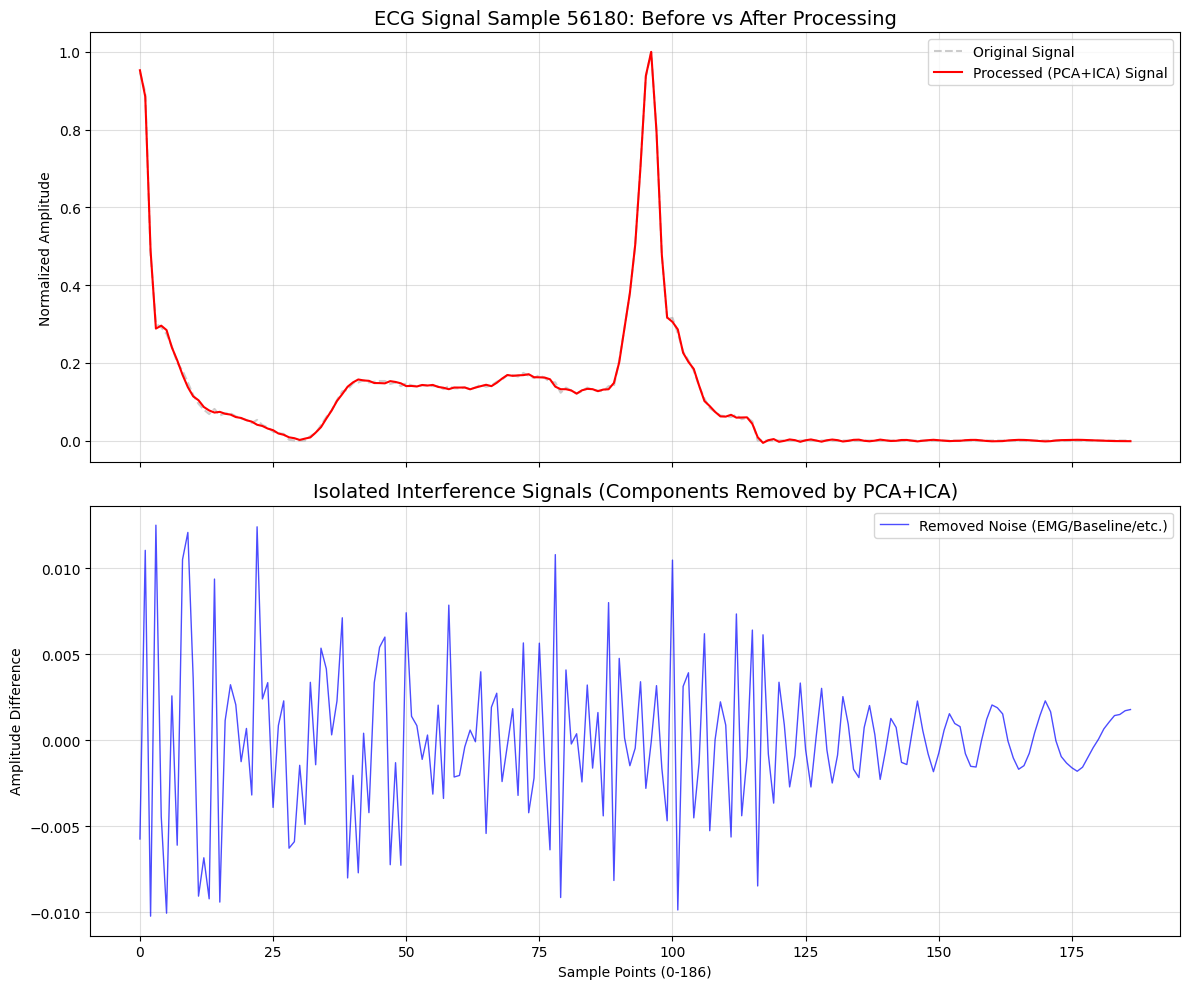

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample_idx = np.random.randint(0, len(X_all))
noise_signal = X_all[sample_idx] - X_final[sample_idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(X_all[sample_idx], label='Original Signal', alpha=0.4, color='gray', linestyle='--')
ax1.plot(X_final[sample_idx], label='Processed (PCA+ICA) Signal', color='red', linewidth=1.5)
ax1.set_title(f"ECG Signal Sample {sample_idx}: Before vs After Processing", fontsize=14)
ax1.set_ylabel("Normalized Amplitude")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.4)

ax2.plot(noise_signal, label='Removed Noise (EMG/Baseline/etc.)', color='blue', linewidth=1, alpha=0.7)
ax2.set_title("Isolated Interference Signals (Components Removed by PCA+ICA)", fontsize=14)
ax2.set_xlabel("Sample Points (0-186)")
ax2.set_ylabel("Amplitude Difference")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Frequency Principal Component Analysis and Filtering

Step 1: Decomposing signal into 50 frequency bands...
Step 2: Performing cumulative loading analysis...
Main characteristic range found: 0Hz - 51Hz
Step 3: Applying combined filter (0-51Hz)...


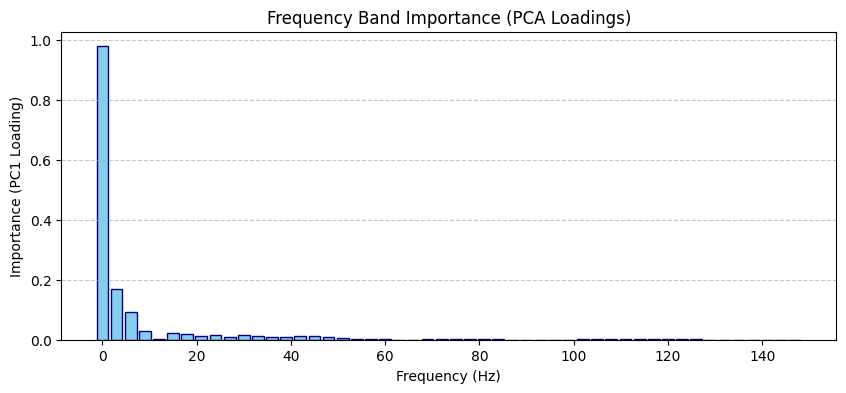

In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def frequency_band_analysis(X_final, fs=360):
    n_samples, n_points = X_final.shape
    low_freqs = np.arange(0, 150, 3)
    high_freqs = low_freqs + 3

    band_energy_matrix = np.zeros((n_samples, len(low_freqs)))
    nyq = 0.5 * fs

    print("Step 1: Decomposing signal into 50 frequency bands...")
    for i, (low, high) in enumerate(zip(low_freqs, high_freqs)):
        temp_low = max(low, 0.01) # Critical frequency must be > 0
        temp_high = min(high, nyq - 0.5)

        # Use bandpass for all 3Hz windows
        b, a = butter(3, [temp_low/nyq, temp_high/nyq], btype='band')
        band_signal = filtfilt(b, a, X_final, axis=1)
        band_energy_matrix[:, i] = np.sqrt(np.mean(band_signal**2, axis=1))

    # PCA Analysis
    print("Step 2: Performing cumulative loading analysis...")
    my_pca_freq = MyPCA(n_components=5, whiten=False)
    X_pca_freq = my_pca_freq.fit_transform(band_energy_matrix)

    loadings = np.abs(my_pca_freq.components_[0])
    loadings_norm = loadings / np.sum(loadings)

    # Sort by load size in descending order and find all frequency bands whose cumulative contribution reaches 99%
    sorted_indices = np.argsort(loadings)[::-1]
    cumulative_importance = np.cumsum(loadings[sorted_indices])
    target_idx = np.where(cumulative_importance >= 0.97 * np.sum(loadings))[0][0]

    # Extract the frequency ranges corresponding to these important frequency bands
    important_indices = sorted_indices[:target_idx + 1]
    selected_lows = low_freqs[important_indices]
    selected_highs = high_freqs[important_indices]

    # Determine the final filter's cutoff frequency (select the union range of these important frequency bands)
    final_low = np.min(selected_lows)
    final_high = np.max(selected_highs)

    final_high = max(final_high, 45.0)
    print(f"Main characteristic range found: {final_low}Hz - {final_high}Hz")

    # Applying optimized filter
    print(f"Step 3: Applying combined filter ({final_low}-{final_high}Hz)...")
    nyq = 0.5 * fs
    low_cutoff = max(final_low, 0.05) / nyq
    high_cutoff = min(final_high, nyq - 0.5) / nyq
    b, a = butter(3, [low_cutoff, high_cutoff], btype='band')
    X_optimized = filtfilt(b, a, X_final, axis=1)
    return X_optimized, low_freqs, loadings

X_optimized, freq_axis, importance = frequency_band_analysis(X_final, fs=360)

# Visualization
plt.figure(figsize=(10, 4))
plt.bar(freq_axis, importance, width=2.5, color='skyblue', edgecolor='navy')
plt.title("Frequency Band Importance (PCA Loadings)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Importance (PC1 Loading)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

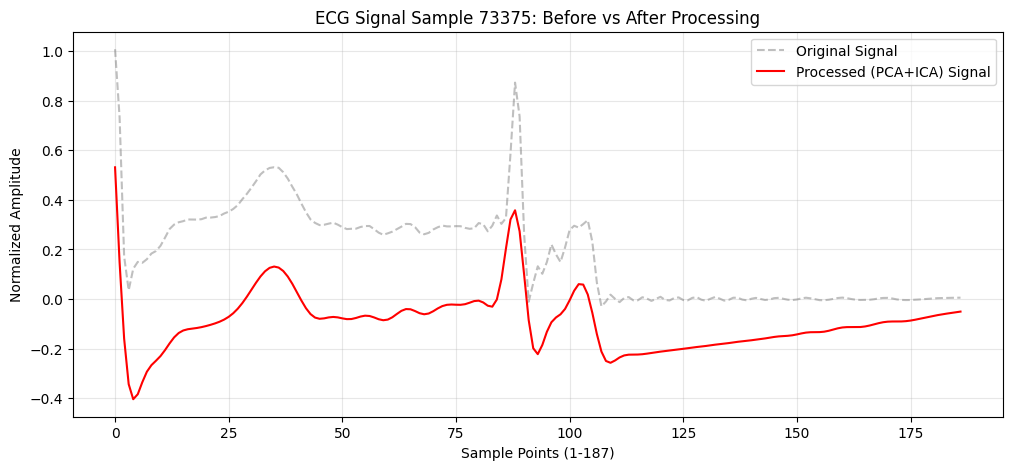

In [ ]:
import matplotlib.pyplot as plt
sample_idx = np.random.randint(0, len(X_all))
plt.figure(figsize=(12, 5))

# original waveform
plt.plot(X_final[sample_idx], label='Original Signal', alpha=0.5, color='gray', linestyle='--')

# processed waveform
plt.plot(X_optimized[sample_idx], label='Processed (PCA+ICA) Signal', color='red', linewidth=1.5)

plt.title(f"ECG Signal Sample {sample_idx}: Before vs After Processing")
plt.xlabel("Sample Points (1-187)")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Using asymmetric Gaussian kernels as basis functions to fit the ECG signals

Fitting 50 samples using dynamic initialization...


Fitting Progress:   0%|          | 0/50 [00:00<?, ?it/s]

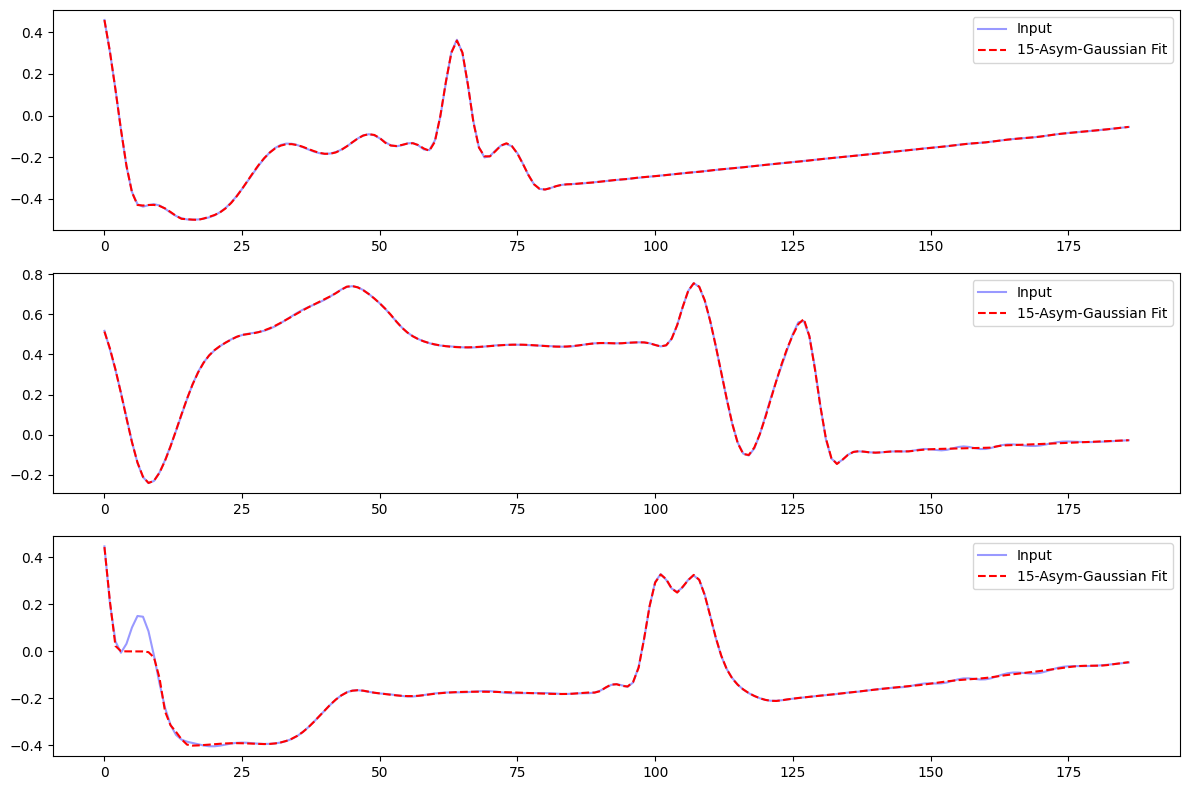

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# Use the asymmetric Gaussian kernel as the basis function
def asymmetric_gaussian(x, amp, mu, sigma_l, sigma_r):
    eps = 1e-6
    sl = np.clip(sigma_l, eps, 50)
    sr = np.clip(sigma_r, eps, 50)
    arg = np.where(x < mu, -((x - mu)**2)/(2*(sl**2)), -((x - mu)**2)/(2*(sr**2)))
    return amp * np.exp(np.clip(arg, -50, 0))

def combined_asym_gaussian(x, *params):
    y = np.zeros_like(x)
    for i in range(0, len(params), 4):
        amp, mu, sl, sr = params[i:i+4]
        y += asymmetric_gaussian(x, amp, mu, sl, sr)
    return y

def fit_single_signal_smart(signal, x_axis, n_kernels):
    signal = signal.astype(np.float64)
    peak_idx = np.argmax(np.abs(signal))
    peak_amp = signal[peak_idx]

    dynamic_guess = []
    for i in range(n_kernels):
        if i == 0: # Main core alignment of R wave
            dynamic_guess.extend([peak_amp, peak_idx, 3.0, 3.0])
        else: # The remaining nuclei are evenly distributed.
            dynamic_guess.extend([0.2 if i%2==0 else -0.1, (187/(n_kernels))*i, 5.0, 5.0])

    try:
        lb = np.array([-2.0, 0.0, 0.1, 0.1] * n_kernels, dtype=np.float64)
        ub = np.array([2.0, 187.0, 40.0, 40.0] * n_kernels, dtype=np.float64)

        popt, _ = curve_fit(combined_asym_gaussian, x_axis, signal,
                            p0=dynamic_guess, bounds=(lb, ub),
                            method='trf', maxfev=3000, xtol=5e-5, ftol=5e-5)
        return popt, combined_asym_gaussian(x_axis, *popt)
    except:
        return np.zeros(n_kernels * 4), np.zeros_like(signal)

def main_processing_flow(X_optimized, y_all, n_per_class=600, n_kernels=15, n_jobs=-1):
    classes = np.unique(y_all)
    balanced_indices = []
    for c in classes:
        indices = np.where(y_all == c)[0]
        selected = np.random.choice(indices, min(len(indices), n_per_class), replace=False)
        balanced_indices.extend(selected)

    np.random.shuffle(balanced_indices)
    X_balanced = X_optimized[balanced_indices]
    y_balanced = y_all[balanced_indices]
    x_axis = np.arange(187).astype(np.float64)

    print(f"Fitting {len(X_balanced)} samples using dynamic initialization...")

    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_single_signal_smart)(X_balanced[i], x_axis, n_kernels)
        for i in tqdm(range(len(X_balanced)), desc="Fitting Progress")
    )

    X_basis_features = np.array([res[0] for res in results])
    X_reconstructed = np.array([res[1] for res in results])
    return X_basis_features, X_reconstructed, y_balanced, X_balanced

X_basis_features, X_rec, y_final, X_orig_sampled = main_processing_flow(X_optimized, y_all, n_per_class=600)

def plot_results(X_orig, X_rec, n=3):
    plt.figure(figsize=(12, 8))
    for i in range(min(n, len(X_orig))):
        plt.subplot(n, 1, i + 1)
        plt.plot(X_orig[i], label='Input', color='blue', alpha=0.4)
        plt.plot(X_rec[i], label='15-Asym-Gaussian Fit', color='red', linestyle='--')
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_results(X_orig_sampled, X_rec)

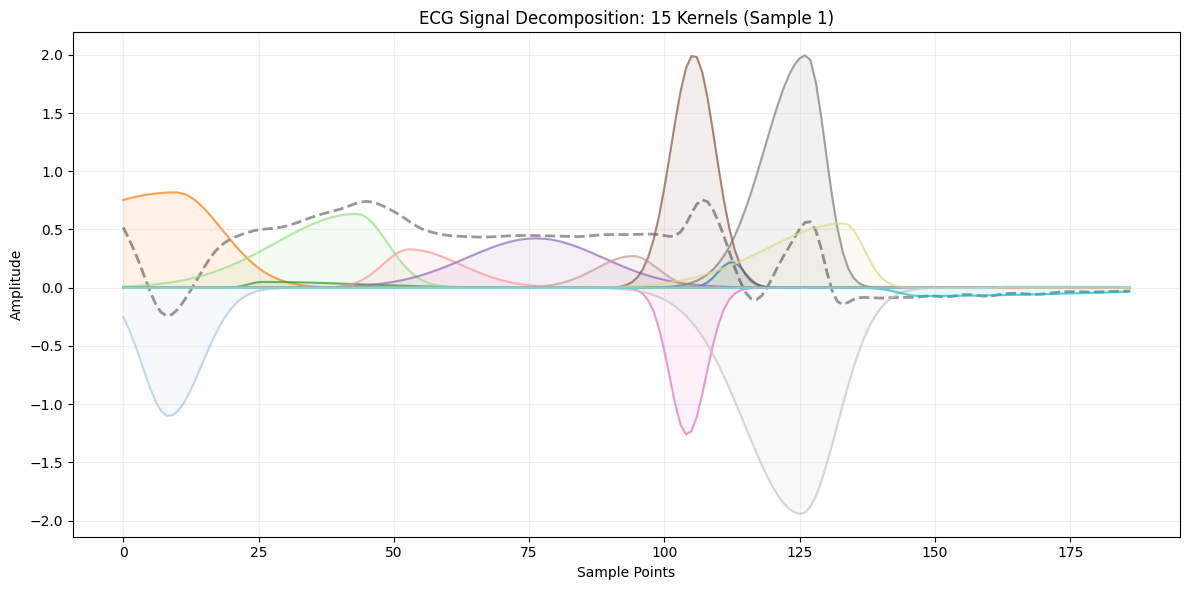

In [ ]:
def plot_decomposed_kernels(X_orig, X_params, sample_idx=0):
    x_axis = np.arange(187).astype(np.float64)
    original_signal = X_orig[sample_idx]
    params = X_params[sample_idx]

    plt.figure(figsize=(12, 6))
    plt.plot(x_axis, original_signal, 'k--', alpha=0.4, label='Original Contour', linewidth=2)
    colors = plt.cm.tab20(np.linspace(0, 1, 15))

    for i in range(15):
        p_slice = params[i*4 : (i+1)*4]
        kernel_y = asymmetric_gaussian(x_axis, *p_slice)
        plt.plot(x_axis, kernel_y, color=colors[i], alpha=0.7)
        plt.fill_between(x_axis, kernel_y, color=colors[i], alpha=0.1)

    plt.title(f"ECG Signal Decomposition: 15 Kernels (Sample {sample_idx})")
    plt.xlabel("Sample Points")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
plot_decomposed_kernels(X_orig_sampled, X_basis_features, sample_idx=1)

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler

def perform_relative_feature_tsne(X_features, y_labels):
    n_samples = X_features.shape[0]
    n_kernels = 15
    processed_features = []

    print("Step 1 & 2: Re-ordering by position and calculating relative differences...")

    for i in range(n_samples):
        sample = X_features[i].reshape(n_kernels, 4)

        sample_sorted = sample[sample[:, 1].argsort()]

        amps = sample_sorted[:, 0]
        mus  = sample_sorted[:, 1]
        sls  = sample_sorted[:, 2]
        srs  = sample_sorted[:, 3]

        d_mus  = np.diff(mus)
        d_amps = np.diff(amps)/d_mus
        d_sls  = np.diff(sls)/d_mus
        d_srs  = np.diff(srs)/d_mus

        combined_56 = np.concatenate([d_amps, d_mus, d_sls, d_srs])
        processed_features.append(combined_56)

    X_diff = np.array(processed_features)

    print("Step 4 & 5: Scaling groups independently...")
    scaler = MinMaxScaler()
    X_final_56 = np.zeros_like(X_diff)
    for group_idx in range(4):
        start, end = group_idx * 14, (group_idx + 1) * 14
        X_final_56[:, start:end] = scaler.fit_transform(X_diff[:, start:end])

    print("Step 6: Running 3D t-SNE on relative features...")
    tsne = TSNE(
        n_components=3,
        perplexity=50,
        init='pca',
        learning_rate='auto',
        random_state=42,
        n_jobs=-1
    )
    X_3d = tsne.fit_transform(X_final_56)

    target_names = ['N', 'S', 'V', 'F', 'Q']
    df = pd.DataFrame(X_3d, columns=['Comp1', 'Comp2', 'Comp3'])
    df['Label'] = [target_names[int(i)] for i in y_labels]

    fig = px.scatter_3d(
        df, x='Comp1', y='Comp2', z='Comp3',
        color='Label',
        title='3D t-SNE: Relative Morphological Differences (56-dim)',
        color_discrete_map={'N':'#1f77b4', 'S':'#ff7f0e', 'V':'#2ca02c', 'F':'#d62728', 'Q':'#9467bd'},
        opacity=0.4
    )

    fig.update_traces(marker=dict(size=2.5, line=dict(width=0)))
    fig.update_layout(legend=dict(itemsizing='constant'))
    fig.show()

    return X_3d
X_tsne_relative = perform_relative_feature_tsne(X_basis_features, y_balanced)

NameError: name 'X_basis_features' is not defined

In [ ]:
# Debugging: Check if the first piece of data has failed to be processed.
from scipy.optimize import curve_fit
import numpy as np
x_test = np.arange(187)
n_kernels = 15
initial_guess = []
for i in range(n_kernels):
    amp_guess = 0.4 if i % 2 == 0 else -0.2
    initial_guess.extend([amp_guess, (187 / (n_kernels + 1)) * (i + 1), 5.0, 5.0])
try:
    popt, _ = curve_fit(combined_asym_gaussian, x_test, X_orig_sampled[0],
                        p0=initial_guess,
                        bounds=([-2.0, 0, 0.1, 0.1]*15, [2.0, 187, 40, 40]*15),
                        method='trf',
                        maxfev=2000,
                        xtol=1e-3,
                        ftol=1e-3)
    print("The fit was successful. Parameters：", popt[:4])
except Exception as e:
    print("Reason for fitting failure：", e)

The fit was successful. Parameters： [-0.40658318  5.15506726  1.05372735 17.86111287]


In [ ]:
print(X_basis_features[0])

[ 1.67050279e+00  1.47576101e+01  1.47194557e+01  6.76755449e+00
 -1.71261421e+00  6.30134546e+00  4.16828476e+00  8.05222745e+00
 -1.38645784e+00  1.77710505e+01  5.32413096e+00  6.54916108e+00
 -1.16967013e+00  5.89897015e+01  1.13700025e+01  3.31564954e+00
  3.31269866e-01  5.72917258e+01  3.94575265e+00  2.31255043e+01
  6.90444252e-01  5.04659822e+01  5.45642088e+00  3.99998148e+01
 -8.19585381e-01  6.80589223e+01  2.35177120e+00  3.31201212e+00
 -9.43459959e-01  7.72052043e+01  5.47288194e+00  4.42889388e+00
 -6.69439851e-01  8.58642281e+01  4.56754858e+00  5.32567747e+00
 -5.60491521e-01  9.60667283e+01  6.07000835e+00  7.24309111e+00
 -3.68782491e-01  1.09816622e+02  7.61525982e+00  9.20868051e+00
 -2.56636407e-01  1.28158044e+02  1.05779214e+01  1.36011747e+01
 -2.60858904e-02  1.50989614e+02  8.82899308e+00  6.21313371e+00
 -1.03756932e-01  1.58182656e+02  1.50031449e+01  6.51385458e+00
 -8.71257833e-02  1.71068391e+02  6.36131504e+00  1.59415829e+01]


t-SNE function amd 3D or 2D plotting

In [ ]:
import numpy as np

class MyTSNE:
    def __init__(self, n_components=3, perplexity=30.0, learning_rate=200.0, n_iter=500, random_state=42):
        self.n_components = n_components
        self.perplexity = perplexity
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        np.random.seed(random_state)

    def _compute_pairwise_distances(self, X):
        sum_X = np.sum(np.square(X), axis=1)
        D = np.add(np.add(-2 * np.dot(X, X.T), sum_X).T, sum_X)
        return np.maximum(D, 0)

    def _get_p_ij(self, D):
        n = 3000 # D.shape
        P = np.zeros((n, n))
        target_entropy = np.log(self.perplexity)

        for i in range(n):
            beta = 1.0  # 1 / (2 * sigma^2)
            betamin, betamax = -np.inf, np.inf

            for _ in range(50): # perplexity
                d_i = D[i, np.concatenate((np.arange(i), np.arange(i+1, n)))]
                p_i = np.exp(-d_i * beta)
                sum_p = np.sum(p_i) + 1e-8
                H = np.log(sum_p) + beta * np.sum(d_i * p_i) / sum_p

                if np.abs(H - target_entropy) < 1e-5: break
                if H > target_entropy:
                    betamin = beta
                    beta = beta * 2. if betamax == np.inf else (beta + betamax) / 2.
                else:
                    betamax = beta
                    beta = beta / 2. if betamin == -np.inf else (beta + betamin) / 2.

            p_i_full = np.exp(-D[i] * beta)
            p_i_full[i] = 0
            P[i] = p_i_full / (np.sum(p_i_full) + 1e-8)

        # symmetrization
        P = (P + P.T) / (2 * n)
        return np.maximum(P, 1e-12)

    def fit_transform(self, X):
        n = 3000 # X.shape
        D = self._compute_pairwise_distances(X)
        P = self._get_p_ij(D)
        P = P * 4.0  # Early Exaggeration
        Y = np.random.randn(n, self.n_components) * 1e-4
        velocity = np.zeros_like(Y)
        momentum = 0.5

        print(f"Start MyTSNE Optimization ({self.n_iter} iterations)...")
        for i in range(self.n_iter):
            # Calculate the low-dimensional similarity Q (t-distribution)
            sum_Y = np.sum(np.square(Y), axis=1)
            num = 1.0 / (1.0 + np.add(np.add(-2 * np.dot(Y, Y.T), sum_Y).T, sum_Y))
            num[np.arange(n), np.arange(n)] = 0
            Q = num / (np.sum(num) + 1e-8)

            # Calculate the gradient
            PQ_diff = P - Q
            grad = np.zeros((n, self.n_components))
            for j in range(n):
                grad[j] = 4 * np.dot((PQ_diff[j] * num[j]), (Y[j] - Y))
            if i == 50: P = P / 4.0
            if i == 100: momentum = 0.8 # Acceleration of momentum convergence

            velocity = momentum * velocity - self.learning_rate * grad
            Y = Y + velocity

            if (i + 1) % 100 == 0: # KL divergence
                kl_div = np.sum(P * np.log(P / (Q + 1e-12) + 1e-12))
                print(f"Iteration {i+1}/{self.n_iter}, KL Divergence: {kl_div:.6f}")

        return Y

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
# from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def main_processing_flow(X_optimized, y_all, n_per_class=600, n_kernels=15, n_jobs=-1):
    classes = np.unique(y_all)
    balanced_indices = []
    for c in classes:
        indices = np.where(y_all == c)[0]
        selected = np.random.choice(indices, min(len(indices), n_per_class), replace=False)
        balanced_indices.extend(selected)

    np.random.shuffle(balanced_indices)
    X_balanced = X_optimized[balanced_indices]
    y_balanced = y_all[balanced_indices]
    x_axis = np.arange(187).astype(np.float64)
    print(f"Fitting {len(X_balanced)} samples using dynamic initialization...")
    return X_balanced, y_balanced

def perform_raw_signal_tsne(X_raw, y_labels):
    # Standardization of the original signal
    print("Step 1: Standardizing raw 187-dim signals...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # My t-SNE
    print("Step 2: Running 3D t-SNE on 187-dim raw data...")
    tsne = MyTSNE(
        n_components=3,
        perplexity=50,
        learning_rate=220,
        n_iter=500,
        random_state=42
    )

    X_3d_raw = tsne.fit_transform(X_scaled)
    target_names = ['N', 'S', 'V', 'F', 'Q']
    df = pd.DataFrame(X_3d_raw, columns=['Comp1', 'Comp2', 'Comp3'])
    df['Label'] = [target_names[int(i)] for i in y_labels]

    fig = px.scatter_3d(
        df, x='Comp1', y='Comp2', z='Comp3',
        color='Label',
        title='3D t-SNE: Raw 187-dim Signal (No Feature Extraction)',
        color_discrete_map={'N':'#1f77b4', 'S':'#ff7f0e', 'V':'#2ca02c', 'F':'#d62728', 'Q':'#9467bd'},
        opacity=0.4
    )

    fig.update_traces(marker=dict(size=2.5, line=dict(width=0)))
    fig.update_layout(legend=dict(itemsizing='constant'))
    fig.show()
    return X_3d_raw

X_balanced, y_balanced = main_processing_flow(X_optimized, y_all, n_per_class=600)
X_raw_tsne_res = perform_raw_signal_tsne(X_balanced, y_balanced)

Fitting 3000 samples using dynamic initialization...
Step 1: Standardizing raw 187-dim signals...
Step 2: Running 3D t-SNE on 187-dim raw data...
Start MyTSNE Optimization (500 iterations)...
Iteration 100/500, KL Divergence: 1.582471
Iteration 200/500, KL Divergence: 0.988851
Iteration 300/500, KL Divergence: 0.852287
Iteration 400/500, KL Divergence: 0.783869
Iteration 500/500, KL Divergence: 0.740931


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def perform_raw_signal_tsne_2d(X_raw, y_labels):
    print("Step 1: Standardizing raw 187-dim signals...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # t-SNE
    print("Step 2: Running 2D t-SNE on 187-dim raw data...")
    tsne = TSNE(
        n_components=2,
        perplexity=50,
        init='pca',
        learning_rate='auto',
        random_state=42,
        n_jobs=-1
    )
    X_2d_raw = tsne.fit_transform(X_scaled)
    target_names = ['N', 'S', 'V', 'F', 'Q']
    df = pd.DataFrame(X_2d_raw, columns=['Component1', 'Component2'])
    df['Label'] = [target_names[int(i)] for i in y_labels]

    fig = px.scatter(
        df,
        x='Component1',
        y='Component2',
        color='Label',
        title='2D t-SNE: Raw 187-dim Signal (No Feature Extraction)',
        color_discrete_map={
            'N':'#1f77b4',
            'S':'#ff7f0e',
            'V':'#2ca02c',
            'F':'#d62728',
            'Q':'#9467bd'
        },
        opacity=0.6
    )

    fig.update_traces(marker=dict(size=5, line=dict(width=0)))
    fig.update_layout(
        legend=dict(itemsizing='constant', title="Class Labels"),
        xaxis_title="t-SNE Dimension 1",
        yaxis_title="t-SNE Dimension 2"
    )
    fig.show()
    return X_2d_raw

X_raw_tsne_2d_res = perform_raw_signal_tsne_2d(X_balanced, y_balanced)

Step 1: Standardizing raw 187-dim signals...
Step 2: Running 2D t-SNE on 187-dim raw data...


Convolutional AutoEncoder and GHA algorithm （maybe some attention layers, but they are not important and can be discard carelessly）

Training CAE+GHA on cpu...
Epoch [10/100] - Total: 0.0041 (Recon: 0.0033)
Epoch [20/100] - Total: 0.0015 (Recon: 0.0012)
Epoch [30/100] - Total: 0.0016 (Recon: 0.0013)
Epoch [40/100] - Total: 0.0011 (Recon: 0.0009)
Epoch [50/100] - Total: 0.0013 (Recon: 0.0011)
Epoch [60/100] - Total: 0.0007 (Recon: 0.0006)
Epoch [70/100] - Total: 0.0009 (Recon: 0.0008)
Epoch [80/100] - Total: 0.0008 (Recon: 0.0007)
Epoch [90/100] - Total: 0.0009 (Recon: 0.0007)
Epoch [100/100] - Total: 0.0012 (Recon: 0.0011)


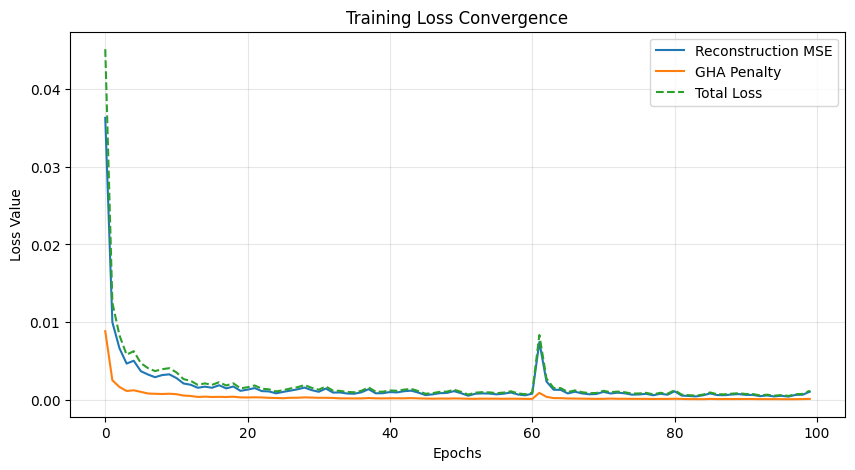

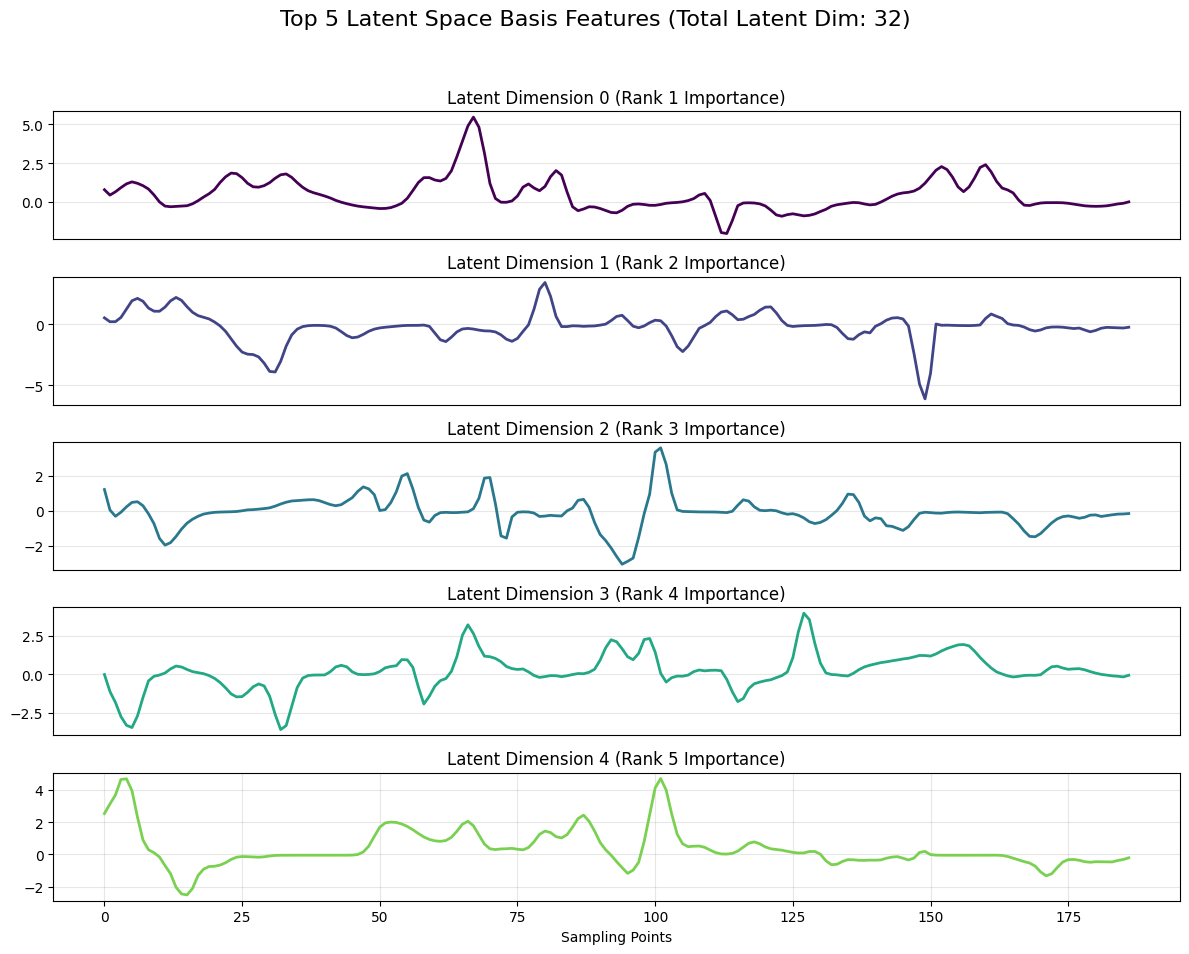

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

def plot_latent_basis_features(model):
    model.eval()
    device = next(model.parameters()).device
    current_latent_dim = model.latent_dim
    x_axis = np.arange(187)

    plt.figure(figsize=(12, 10))
    plt.suptitle(f"Top 5 Latent Space Basis Features (Total Latent Dim: {current_latent_dim})", fontsize=16)

    for i in range(5):
        z = torch.zeros((1, current_latent_dim)).to(device)
        z[0, i] = 3.0
        with torch.no_grad():
            reconstructed_feature = model.decoder(z)
            feature_wave = reconstructed_feature.cpu().numpy().flatten()
        plt.subplot(5, 1, i + 1)
        plt.plot(x_axis, feature_wave, color=plt.cm.viridis(i/5), linewidth=2)
        plt.title(f"Latent Dimension {i} (Rank {i+1} Importance)")
        plt.grid(alpha=0.3)
        if i < 4: plt.xticks([])
    plt.xlabel("Sampling Points")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv1d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        y = torch.cat([avg_out, max_out], dim=1)
        y = self.conv(y)
        return x * self.sigmoid(y)

class ConvGHA_Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(ConvGHA_Autoencoder, self).__init__()
        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, stride=1, padding=5),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),
            nn.MaxPool1d(2), # 187 -> 93
            SpatialAttention(),

            nn.Conv1d(16, 32, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.MaxPool1d(2), # 93 -> 46
            #SEBlock(32),

            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            SEBlock(64)
        )

        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 46, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, latent_dim)
        )


        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 64 * 46),
            nn.LeakyReLU(0.2),
            nn.Unflatten(1, (64, 46))
        )

        self.decoder_conv = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            SEBlock(64),

            nn.Upsample(size=93, mode='linear', align_corners=True),
            nn.Conv1d(64, 32, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            #SEBlock(32),

            nn.Upsample(size=187, mode='linear', align_corners=True),
            nn.Conv1d(32, 16, kernel_size=11, stride=1, padding=5),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),
            SpatialAttention(),

            nn.Conv1d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.AdaptiveAvgPool1d(187)
        )

    def encoder(self, x):
      return self.encoder_fc(self.encoder_conv(x))

    def decoder(self, z):
      return self.decoder_conv(self.decoder_fc(z))

    def forward(self, x):
      latent = self.encoder(x)
      reconstructed = self.decoder(latent)
      return reconstructed, latent

# GHA
def gha_sorting_loss(latent):
    latent_centered = latent - latent.mean(dim=0)
    cov = torch.mm(latent_centered.t(), latent_centered) / (latent.shape[0] - 1 + 1e-6)
    weights = torch.linspace(1.0, 0.1, steps=latent.shape[1]).to(latent.device)
    var_loss = -torch.mean(torch.var(latent, dim=0) * weights)
    identity = torch.eye(latent.shape[1]).to(latent.device)
    ortho_loss = torch.norm(cov * (1 - identity))
    return 0.01 * var_loss, 0.1 * ortho_loss

# Loss
def train_and_extract_latent(X_raw, y_labels, latent_dim=32, epochs=60):
    X_tensor = torch.FloatTensor(X_raw).unsqueeze(1)
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_tensor), batch_size=64, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConvGHA_Autoencoder(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    mse_criterion = nn.MSELoss()

    history = {'recon_loss': [], 'gha_loss': [], 'total_loss': []}

    print(f"Training CAE+GHA on {device}...")
    for epoch in range(epochs):
        model.train()
        epoch_recon, epoch_gha, epoch_total = 0, 0, 0

        for batch in loader:
            inputs = batch[0].to(device)
            optimizer.zero_grad()
            recon, latent = model(inputs)

            loss_recon = mse_criterion(recon, inputs)
            l_var, l_ortho = gha_sorting_loss(latent)
            loss_gha = l_var + l_ortho

            total_loss = loss_recon + loss_gha
            total_loss.backward()
            optimizer.step()

            epoch_recon += loss_recon.item()
            epoch_gha += loss_gha.item()
            epoch_total += total_loss.item()

        history['recon_loss'].append(epoch_recon / len(loader))
        history['gha_loss'].append(epoch_gha / len(loader))
        history['total_loss'].append(epoch_total / len(loader))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Total: {history['total_loss'][-1]:.4f} (Recon: {history['recon_loss'][-1]:.4f})")

    plt.figure(figsize=(10, 5))
    plt.plot(history['recon_loss'], label='Reconstruction MSE')
    plt.plot(history['gha_loss'], label='GHA Penalty')
    plt.plot(history['total_loss'], label='Total Loss', linestyle='--')
    plt.title("Training Loss Convergence")
    plt.xlabel("Epochs")
    plt.ylabel("Loss Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    model.eval()
    plot_latent_basis_features(model)

    with torch.no_grad():
        _, all_latent = model(X_tensor.to(device))
        X_latent = all_latent.cpu().numpy()

    return X_latent

X_latent_features = train_and_extract_latent(X_balanced, y_balanced, latent_dim=32, epochs=100)

In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=3, perplexity=45, random_state=42)
X_3d = tsne.fit_transform(X_latent_features)

target_names = ['N', 'S', 'V', 'F', 'Q']
df = pd.DataFrame(X_3d, columns=['C1', 'C2', 'C3'])
df['Label'] = [target_names[int(i)] for i in y_balanced]
fig = px.scatter_3d(df, x='C1', y='C2', z='C3', color='Label', opacity=0.5,
                     title="3D Visualization of 32-dim Latent Space (CAE + GHA)")
fig.update_traces(marker=dict(size=3))
fig.show()

In [ ]:
from sklearn.manifold import TSNE
import plotly.express as px
import pandas as pd

tsne = TSNE(n_components=2, perplexity=45, random_state=42, n_jobs=-1)
X_2d = tsne.fit_transform(X_latent_features)

target_names = ['N', 'S', 'V', 'F', 'Q']
df_2d = pd.DataFrame(X_2d, columns=['Component 1', 'Component 2'])
df_2d['Label'] = [target_names[int(i)] for i in y_balanced]

fig = px.scatter(
    df_2d,
    x='Component 1',
    y='Component 2',
    color='Label',
    opacity=0.6,
    title="2D Visualization of 32-dim Latent Space (CAE + GHA)",
    color_discrete_map={'N':'#1f77b4', 'S':'#ff7f0e', 'V':'#2ca02c', 'F':'#d62728', 'Q':'#9467bd'}
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(legend=dict(itemsizing='constant'))

fig.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def evaluate_clusters(X, labels, name):
    s_score = silhouette_score(X, labels)
    ch_score = calinski_harabasz_score(X, labels)
    db_score = davies_bouldin_score(X, labels)

    print(f"--- {name} Evaluation ---")
    print(f"Silhouette Score (↑): {s_score:.4f}")
    print(f"CH Index (↑):         {ch_score:.2f}")
    print(f"DB Index (↓):         {db_score:.4f}\n")
    return s_score, ch_score, db_score

results_raw = evaluate_clusters(X_raw_tsne_2d_res, y_balanced, "Raw 187-dim Signal")
results_cae = evaluate_clusters(X_2d, y_balanced, "CAE + GHA Latent Space")

--- Raw 187-dim Signal Evaluation ---
Silhouette Score (↑): 0.0700
CH Index (↑):         443.35
DB Index (↓):         3.6076

--- CAE + GHA Latent Space Evaluation ---
Silhouette Score (↑): 0.0927
CH Index (↑):         527.14
DB Index (↓):         8.8629

